In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)



df = pd.read_csv(
    "../data/kepler_exoplanet_classification.csv"
)
print(df.shape)
df.head()

(7586, 10)


,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_impact,koi_prad,koi_teq,koi_insol,koi_model_snr
0,K00752.01,CONFIRMED,9.488036,2.95750,615.8,0.146,2.26,793.0,93.59,35.8
1,K00752.02,CONFIRMED,54.418383,4.50700,874.8,0.586,2.83,443.0,9.11,25.8
2,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,1.276,33.46,1395.0,891.96,505.6
3,K00755.01,CONFIRMED,2.525592,1.65450,603.3,0.701,2.75,1406.0,926.16,40.9
4,K00756.01,CONFIRMED,11.094321,4.59450,1517.5,0.538,3.90,835.0,114.81,66.5


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7586 entries, 0 to 7585
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kepoi_name       7586 non-null   str    
 1   koi_disposition  7586 non-null   str    
 2   koi_period       7586 non-null   float64
 3   koi_duration     7586 non-null   float64
 4   koi_depth        7327 non-null   float64
 5   koi_impact       7327 non-null   float64
 6   koi_prad         7327 non-null   float64
 7   koi_teq          7327 non-null   float64
 8   koi_insol        7367 non-null   float64
 9   koi_model_snr    7327 non-null   float64
dtypes: float64(8), str(2)
memory usage: 592.8 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
koi_period,7586.0,51.655891,111.831884,0.241843,2.243126,8.080979,30.55289,1.071233e+03
koi_duration,7586.0,5.712879,6.825779,0.104600,2.474975,3.836305,6.27100,1.385400e+02
koi_depth,7327.0,29525.640794,91164.509271,0.800000,182.700000,501.400000,2319.00000,1.541400e+06
koi_impact,7327.0,0.756030,3.196172,0.000000,0.227000,0.586000,0.91700,1.008060e+02
koi_prad,7327.0,104.156288,3180.266619,0.080000,1.500000,2.620000,24.18000,2.003460e+05
koi_teq,7327.0,1154.390064,900.585687,92.000000,581.000000,933.000000,1482.00000,1.466700e+04
koi_insol,7367.0,9391.243767,178173.484284,0.020000,27.210000,180.550000,1151.57500,1.094755e+07
koi_model_snr,7327.0,318.587062,881.036417,0.000000,15.400000,30.500000,114.85000,9.054700e+03


In [4]:
df["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
Name: count, dtype: int64

<Axes: xlabel='koi_disposition', ylabel='count'>

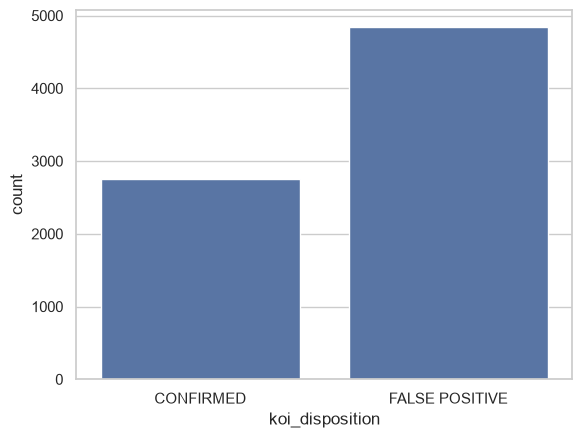

In [5]:
sns.countplot(data=df, x="koi_disposition")

In [6]:
missing = df.isna().sum().sort_values()
features = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_impact",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr"
]

missing_mask = df[features].isna().any(axis=1)

rows_with_missing = missing_mask.sum()
missing_percent = missing_mask.mean() * 100

print("All rows:", len(df))
print("Rows with missing:", rows_with_missing)
print(f"Missing percent: {missing_percent:.2f}%")

All rows: 7586
Rows with missing: 259
Missing percent: 3.41%


In [7]:
print("Classes in data:")
print(df["koi_disposition"].value_counts(normalize=True))

print("\Classes distribution:")
print(
    df.loc[missing_mask, "koi_disposition"]
    .value_counts(normalize=True)
)

Classes in data:
koi_disposition
FALSE POSITIVE    0.637886
CONFIRMED         0.362114
Name: proportion, dtype: float64
\Classes distribution:
koi_disposition
FALSE POSITIVE    0.992278
CONFIRMED         0.007722
Name: proportion, dtype: float64


<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
C:\Users\kamil\AppData\Local\Temp\ipykernel_50704\478000147.py:4: SyntaxWarning: invalid escape sequence '\C'
  print("\Classes distribution:")


In [8]:

df_clean = df.dropna(subset=features).copy()
df_clean.isna().sum()

kepoi_name         0
koi_disposition    0
koi_period         0
koi_duration       0
koi_depth          0
koi_impact         0
koi_prad           0
koi_teq            0
koi_insol          0
koi_model_snr      0
dtype: int64

In [9]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical:", len(numeric_cols))
print("Categorical:", categorical_cols)

Numerical: 8
Categorical: ['kepoi_name', 'koi_disposition']


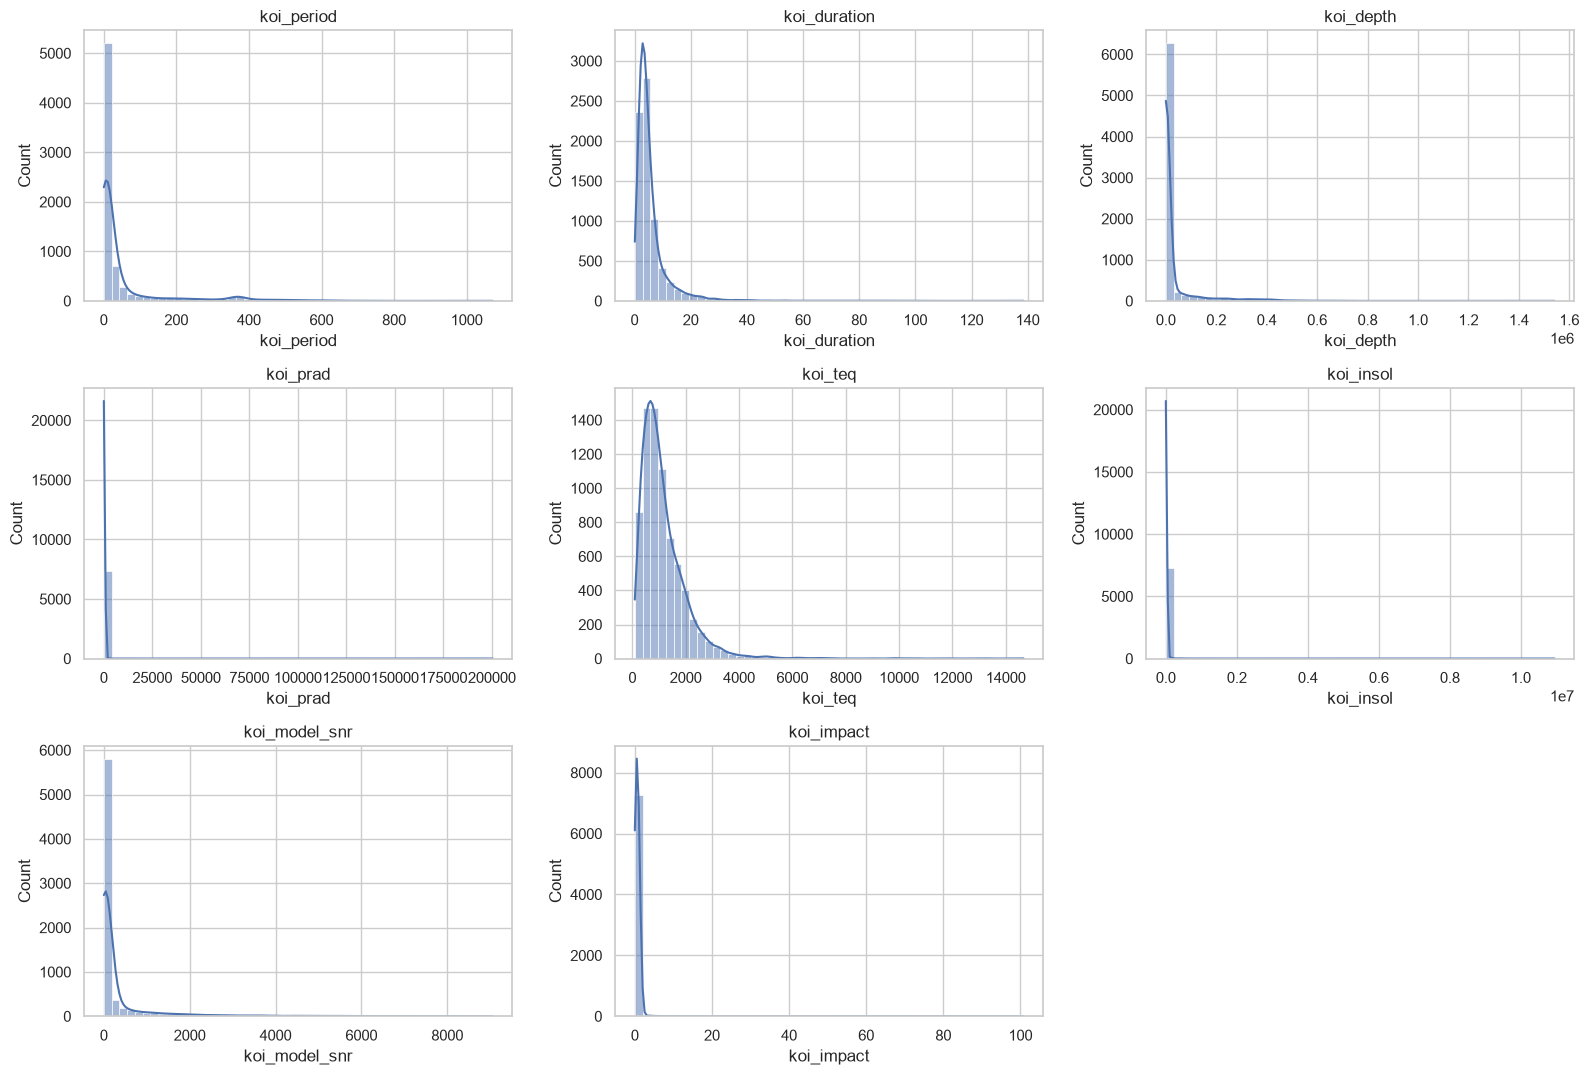

In [10]:
key_features = ["koi_period", "koi_duration", "koi_depth", "koi_prad",
                 "koi_teq", "koi_insol", "koi_model_snr", "koi_impact"
                ]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(key_features):
    if col in df_clean.columns:
        sns.histplot(df_clean[col], bins=50, ax=axes[i], kde=True)
        axes[i].set_title(col)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

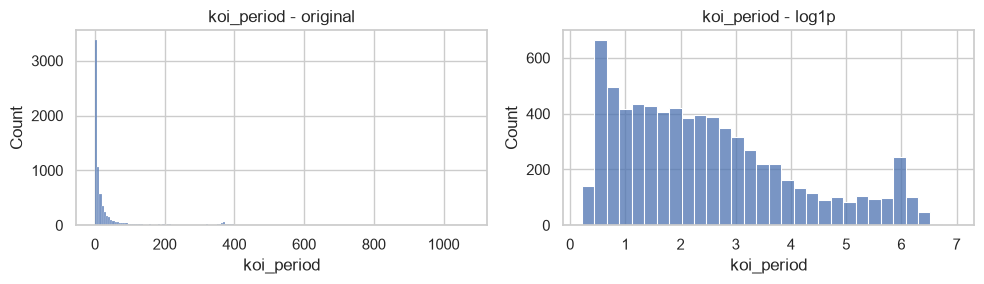

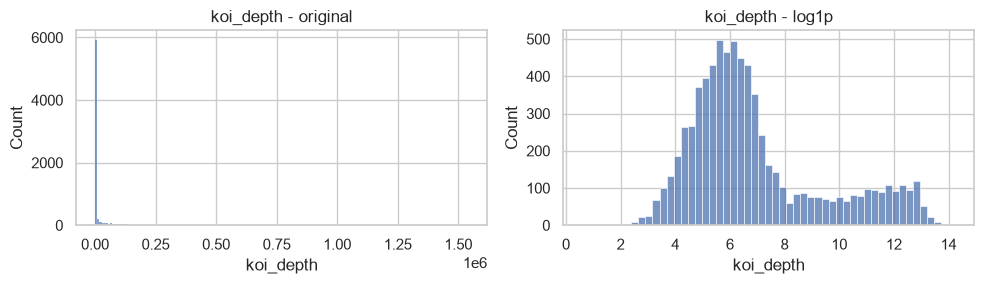

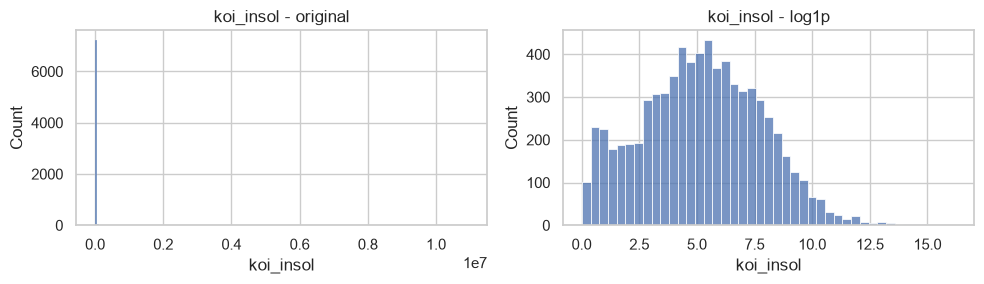

In [11]:
for col in ["koi_period", "koi_depth", "koi_insol"]:
    if col in df_clean.columns:
        fig, ax = plt.subplots(1, 2, figsize=(10, 3))
        sns.histplot(df_clean[col], ax=ax[0]).set_title(f"{col} - original")
        sns.histplot(np.log1p(df_clean[col]), ax=ax[1]).set_title(f"{col} - log1p")
        plt.tight_layout()
        plt.show()

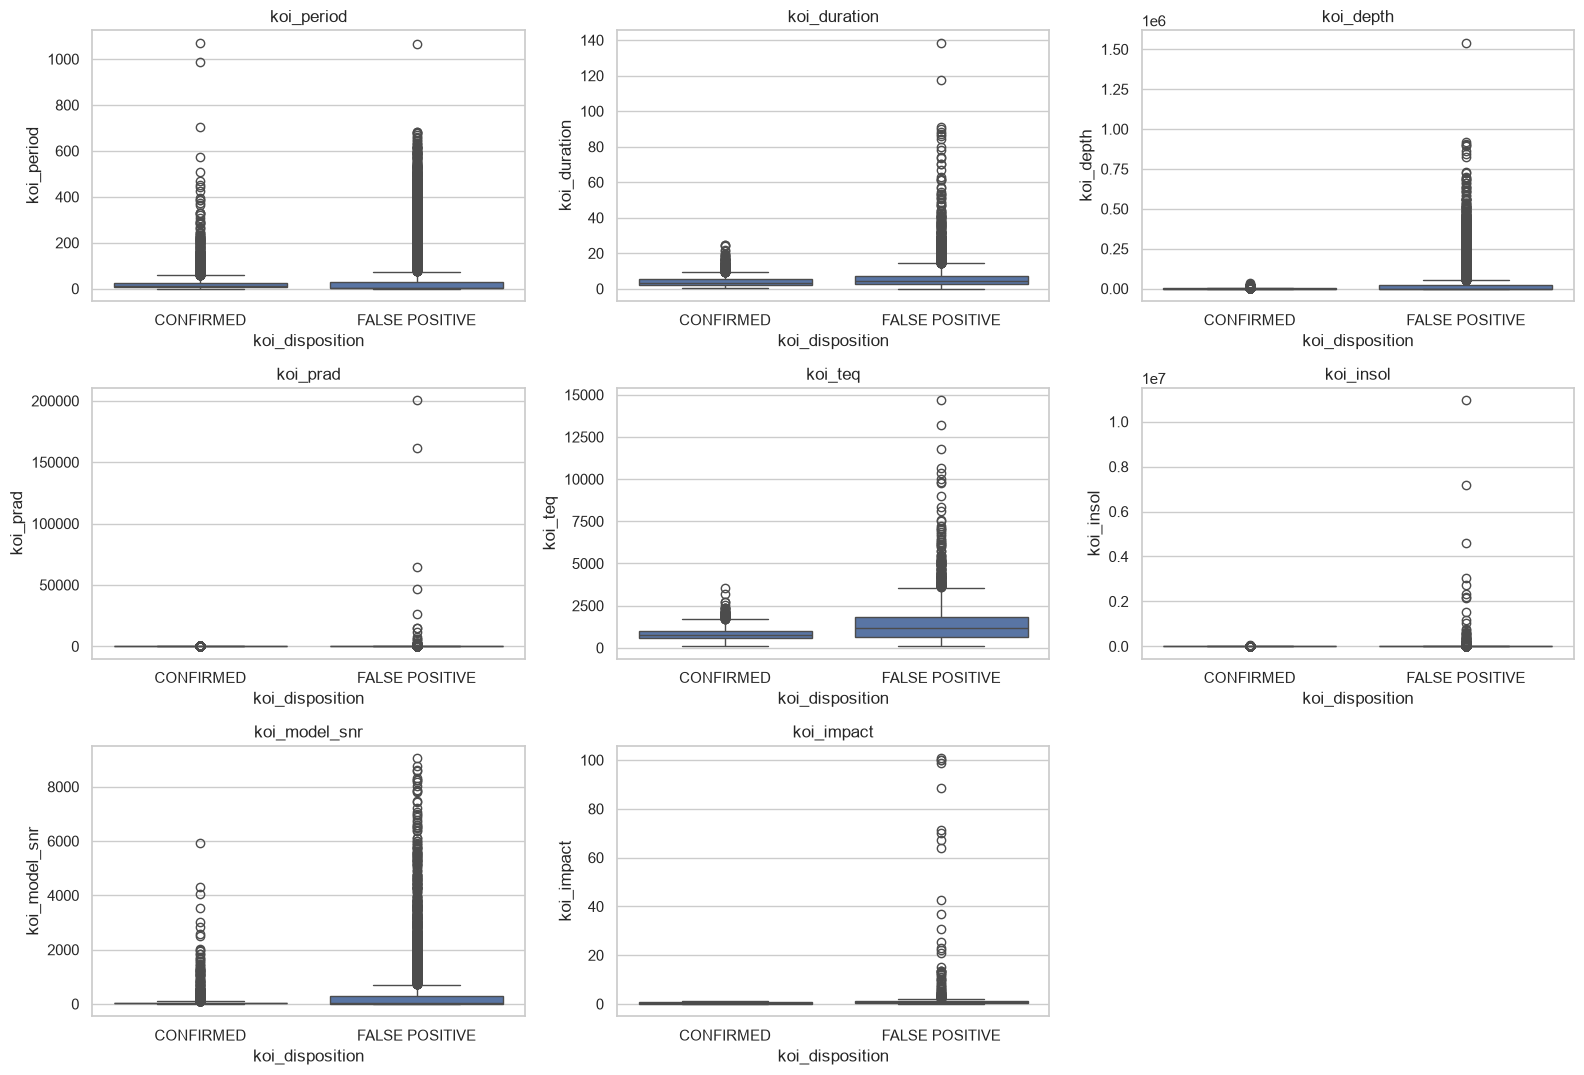

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
target = "koi_disposition"
axes = axes.flatten()
for i, col in enumerate(key_features):
    if col in df_clean.columns:
        sns.boxplot(data=df_clean, x=target, y=col, ax=axes[i])
        axes[i].set_title(col)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

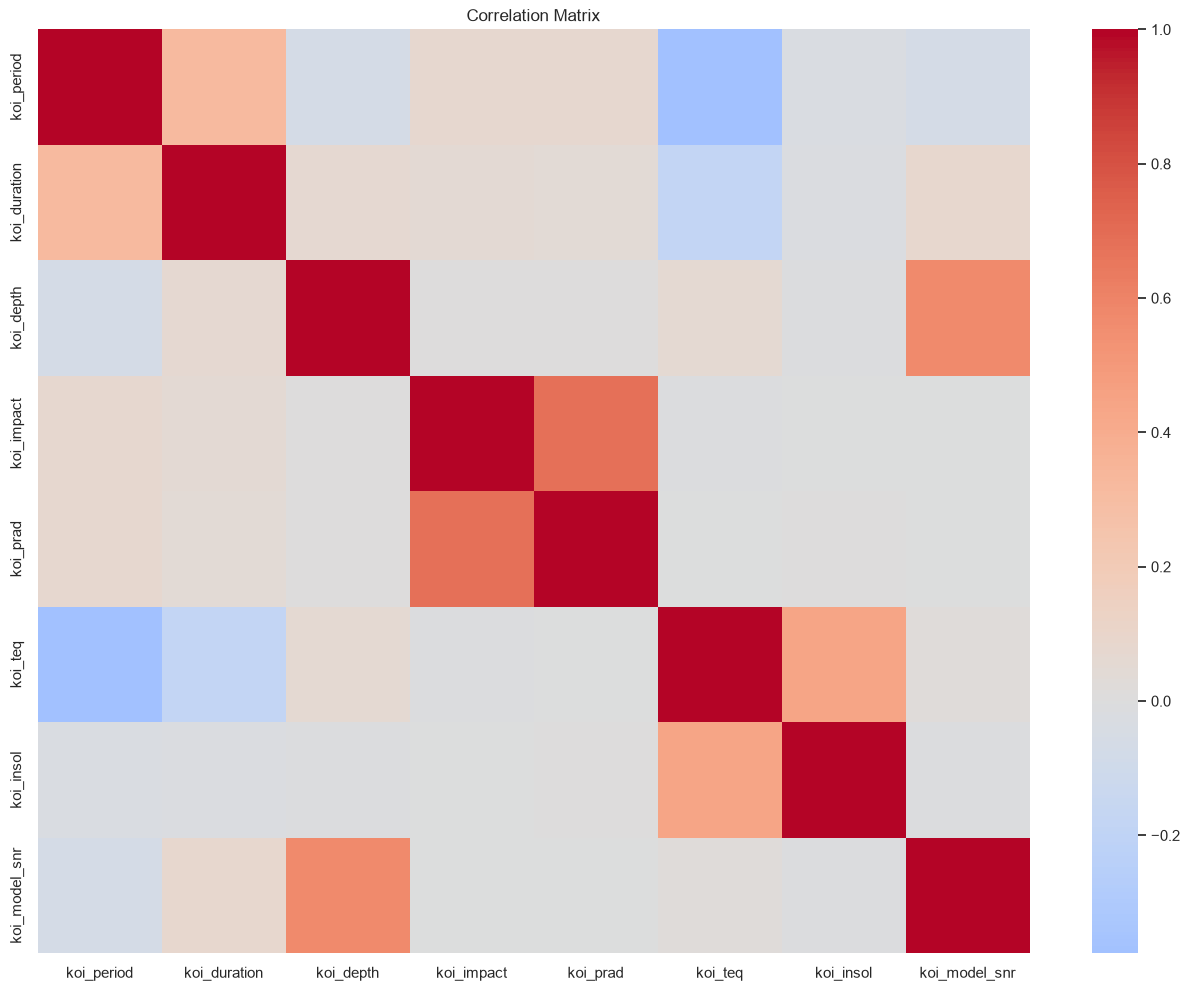

In [13]:
plt.figure(figsize=(16,12))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm",center=0,annot=False)
plt.title("Correlation Matrix")
plt.show()

In [14]:
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
corr_pairs.head(20)

koi_impact     koi_prad         0.679559
koi_model_snr  koi_depth        0.571673
koi_teq        koi_insol        0.440927
koi_period     koi_teq          0.375928
koi_duration   koi_period       0.321165
koi_teq        koi_duration     0.187361
koi_duration   koi_model_snr    0.086036
koi_prad       koi_period       0.075953
koi_period     koi_impact       0.072043
koi_depth      koi_duration     0.068467
               koi_teq          0.063922
koi_model_snr  koi_period       0.061272
koi_depth      koi_period       0.059827
koi_duration   koi_impact       0.048845
koi_prad       koi_duration     0.043572
koi_model_snr  koi_teq          0.025606
koi_period     koi_insol        0.022988
koi_insol      koi_duration     0.019937
koi_impact     koi_teq          0.014331
koi_insol      koi_model_snr    0.011346
dtype: float64

In [15]:
def outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, round(n_out / series.notna().sum() * 100, 2)

for col in key_features:
    if col in df_clean.columns:
        n, pct = outlier_summary(df_clean[col].dropna())
        print(f"{col}: {n} outliers ({pct}%)")

koi_period: 1118 outliers (15.26%)
koi_duration: 667 outliers (9.1%)
koi_depth: 1550 outliers (21.15%)
koi_prad: 780 outliers (10.65%)
koi_teq: 302 outliers (4.12%)
koi_insol: 1111 outliers (15.16%)
koi_model_snr: 1310 outliers (17.88%)
koi_impact: 72 outliers (0.98%)


In [16]:
df_clean.to_csv("../data/kepler_eda_clean.csv")